In [1]:
from typing import Dict, List, Any, Tuple
import numpy as np
from numpy.typing import NDArray
import pandas as pd

from model_ranking import (
    get_summary_results, 
    results_to_arrays,
    per_source_model_results,
    cmb_consistency_score_weighted_average,
    per_target_consis_result_type,
    per_target_performance_result_type,
)
from model_ranking import plot_alpha_sweep_specific_norm
from model_ranking import (
    calculate_correlation_statistics
)

INFO: P [MainThread] 2025-10-07 10:17:14,305 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
NA_UNet_source_models = {
    "PNAS": "p_model_NA1",
    "Ovules": "ov_model_NA1",
}
Res_source_models = {
    "FlyWing": "fw_model_Res2",
    "Ovules": "ov_model_Res1",
    "PNAS": "p_model_Res1",
}

Unetr_source_models = {
    "FlyWing": "fw_model_Unetr2",
    "Ovules": "ov_model_Unetr1",
    "PNAS": "p_model_Unetr1",
}
Unet_source_models={
    "FlyWing": "fw_model_Unet2",
    "Ovules": "ov_model_UNet1",
    "PNAS": "p_model_UNet1",
}
consis_keys={
    "FlyWing": "AdaRandError_consis",
    "Ovules": "AdaRandError_consis",
    "PNAS": "AdaRandError_consis",
}
# consis_keys_bckg = {
#     "FlyWing": "AdaRandError_consis_bckg",
#     "Ovules": "AdaRandError_consis_bckg",
#     "PNAS": "AdaRandError_consis_bckg",
# }
result_folders={
    "FlyWing": "P_full",
    "Ovules": "P_full",
    "PNAS": "P_full",
}

per_target_norms: Dict[str, List[Tuple[float,float]]] = {
    "FlyWing": [(5.0, 95.0)],
    "Ovules": [(5.0, 95.0)],
    "PNAS": [(5.0, 95.0)],
}

perf_key = "MAP_05_095"
approach="consistency"
base_result_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells"

In [17]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
    #"gauss": ["a001-003", "a003-005", "a005-007", "a007-01", "a01-02"],
    "gauss": ["a003-005", "a005-007", "a007-01", "a01-02"],
}
targets = ["FlyWing", "Ovules", "PNAS"]
source_model_types = [NA_UNet_source_models, Res_source_models, Unet_source_models, Unetr_source_models]
#source_model_types = [Unet_source_models]

In [18]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
sources = ["FlyWing", "Ovules", "PNAS"]
for i, target in enumerate(targets):
        
    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    for model_type in source_model_types:
        if "NA" in model_type["PNAS"]:
            sources = ["Ovules", "PNAS"]
        
        else:
            sources = ["FlyWing", "Ovules", "PNAS"]
            
        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: Ovules


100%|██████████| 1/1 [00:00<00:00, 47.39it/s]


Source: PNAS


100%|██████████| 1/1 [00:00<00:00, 52.66it/s]


Source: FlyWing


...

100%|██████████| 1/1 [00:00<00:00, 42.99it/s]


Source: Ovules


100%|██████████| 1/1 [00:00<00:00, 40.25it/s]


Source: PNAS


100%|██████████| 1/1 [00:00<00:00, 41.88it/s]


In [19]:
per_target_forg_consistency

{'FlyWing': {'ov_model_NA1': {'norm_50_950': {'gauss': array([0.84524012, 0.95004284, 0.9361068 , 0.95234287])}},
  'p_model_NA1': {'norm_50_950': {'gauss': array([0.02134294, 0.0551767 , 0.08312898, 0.14511552])}},
  'fw_model_Res2': {'norm_50_950': {'gauss': array([0.00072854, 0.00289268, 0.00621671, 0.01407018])}},
  'ov_model_Res1': {'norm_50_950': {'gauss': array([0.15031216, 0.39090171, 0.76080114, 0.94505644])}},
  'p_model_Res1': {'norm_50_950': {'gauss': array([0.06284304, 0.1387337 , 0.20862603, 0.26867217])}},
  'fw_model_Unet2': {'norm_50_950': {'gauss': array([0.00152213, 0.00348403, 0.00760267, 0.01823688])}},
  'ov_model_UNet1': {'norm_50_950': {'gauss': array([0.00834147, 0.01768792, 0.02128219, 0.03930717])}},
  'p_model_UNet1': {'norm_50_950': {'gauss': array([0.01490499, 0.02924679, 0.04456635, 0.07146377])}},
  'fw_model_Unetr2': {'norm_50_950': {'gauss': array([0.00163363, 0.00293867, 0.00549811, 0.01068493])}},
  'ov_model_Unetr1': {'norm_50_950': {'gauss': array(

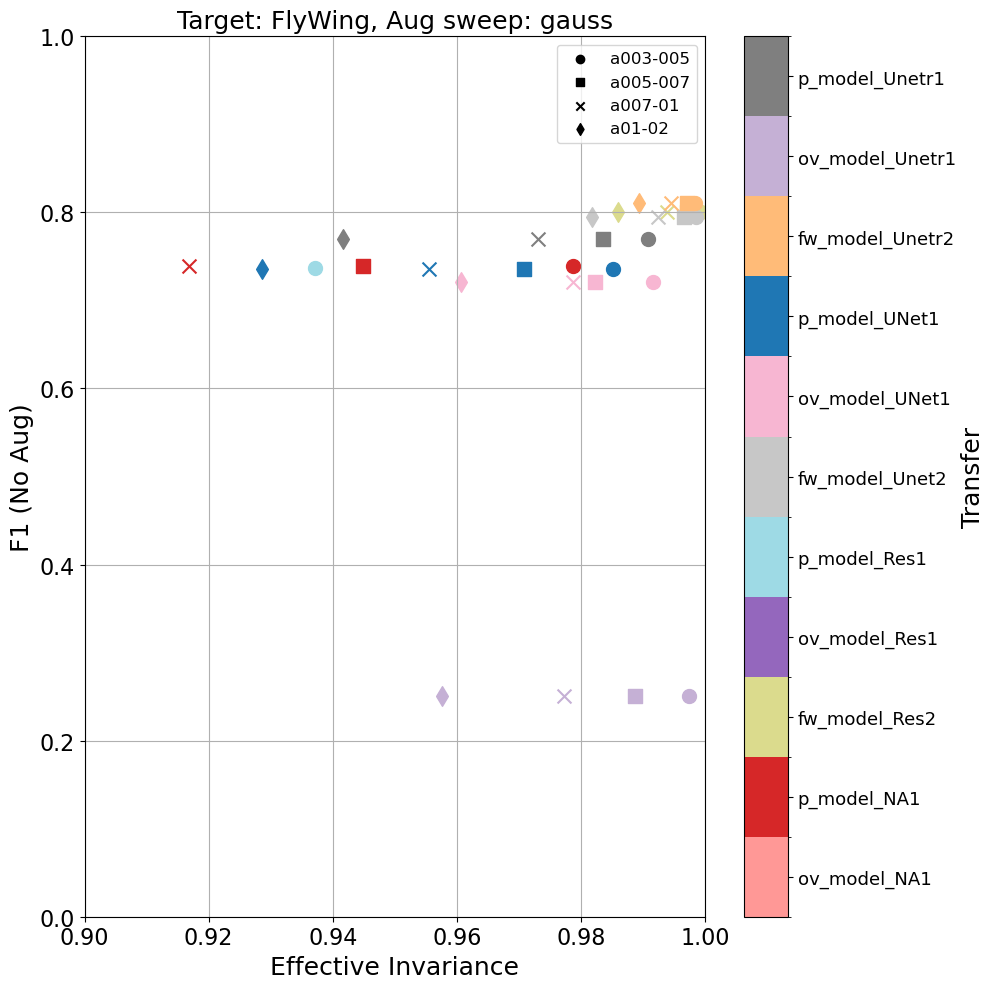

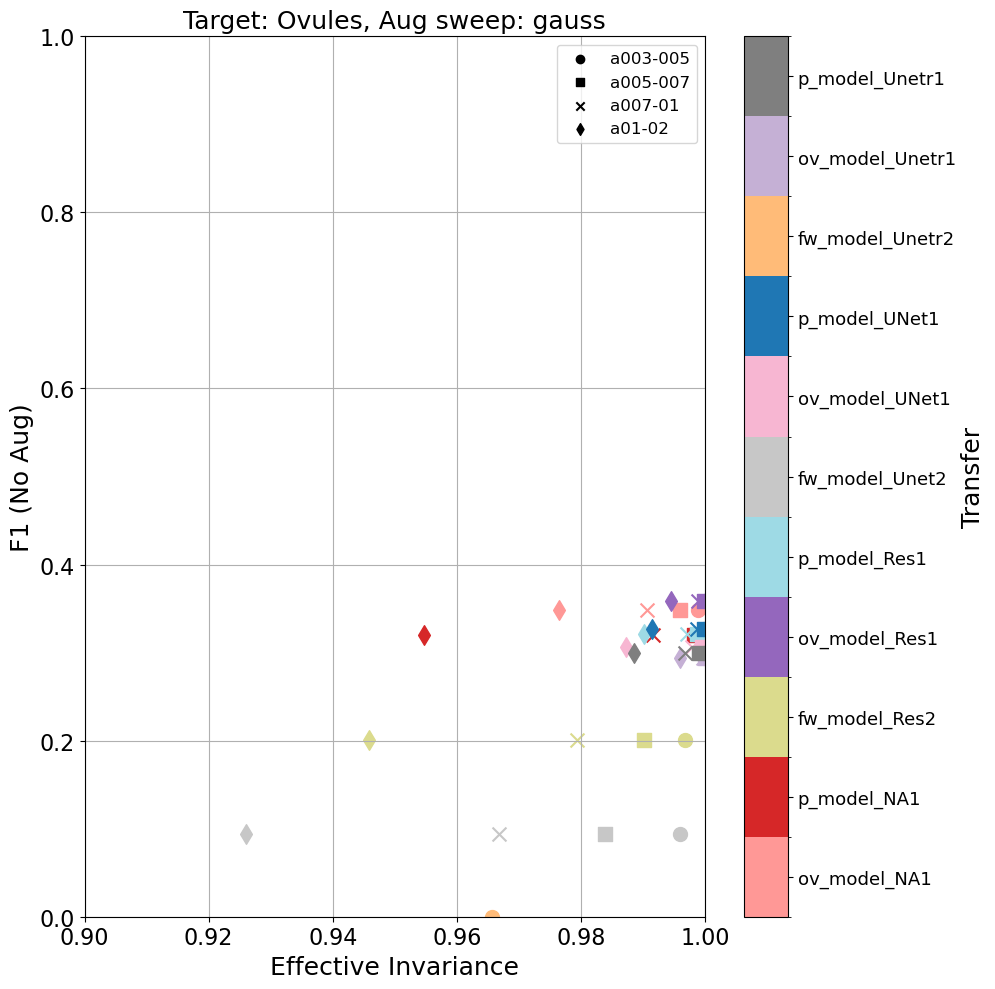

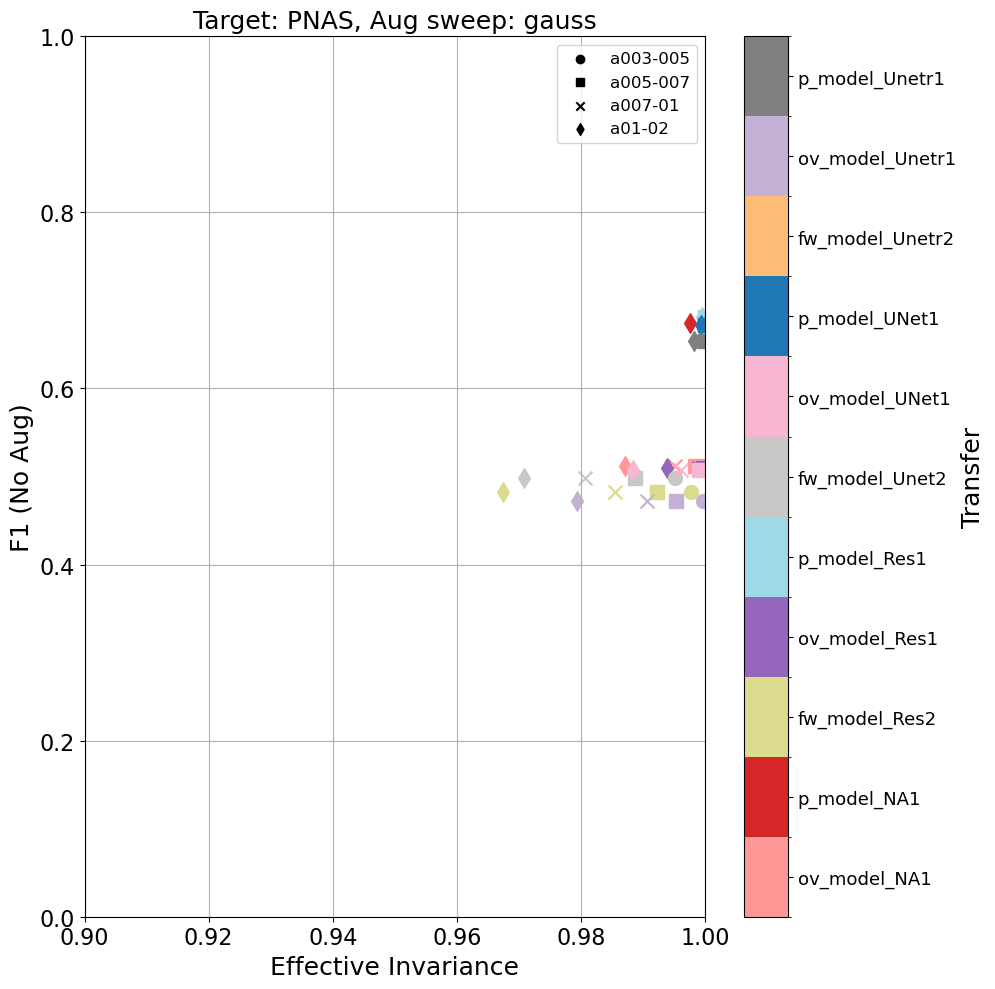

In [20]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= True,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0.9, 1),
        n_rows=1,
        n_cols = 1,
    )